In [14]:
import math
import os

import numpy as np
import matplotlib.pyplot as plt
import random
from dataclasses import dataclass

Ciekawe wnioski:
 - uzupełnianie wierszy daje gorsze wyniki niz wypelnianie kwadratow

Funkcja wczytuje stany planszy z pliku

In [15]:
def load_from_file(filename):
    matrix = np.zeros((9, 9))

    with open(filename) as f:
        prior = set()
        for j, line in enumerate(f.readlines()):
            lines = line.strip().split(" ")

            for i, c in enumerate(lines):
                if c != 'x':
                    matrix[j][i] = int(c)
                    prior.add((j, i))
                else:
                    matrix[j][i] = 0

    for br in range(3):
        for bc in range(3):
            present_numbers = []
            for r in range(br * 3, (br + 1) * 3):
                for c in range(bc * 3, (bc + 1) * 3):
                    if matrix[r][c] != 0:
                        present_numbers.append(matrix[r][c])

            missing_numbers = [n for n in range(1, 10) if n not in present_numbers]
            random.shuffle(missing_numbers)

            for r in range(br * 3, (br + 1) * 3):
                for c in range(bc * 3, (bc + 1) * 3):
                    if matrix[r][c] == 0:
                        matrix[r][c] = missing_numbers.pop()

    matrix = matrix.astype(int)

    return matrix, prior


Funkcja wylicza wartość planszy. Jest to licza powtórzeń w wierszach, kolumnach i kwadratach

In [22]:
def get_value(matrix):
    sum = 0

    matrix = np.array(matrix)

    if matrix.ndim == 1:
        matrix = matrix.reshape(9, 9)

    for i in range(9):
        row = matrix[i, :]
        counts = np.bincount(row, minlength=9)
        sum += counts[counts > 1].sum()

    for i in range(9):
        col = matrix[:, i]
        counts = np.bincount(col, minlength=9)
        sum += counts[counts > 1].sum()

    for r in range(3):
        for c in range(3):
            sq = matrix[r*3:(r+1)*3, c*3:(c+1)*3]
            counts = np.bincount(sq.ravel())
            sum += counts[counts > 1].sum()
    return sum

Stan sąsiedni generujemy poprzez losowe zamiany wewnątrz kwadratów. Zamiany wewnątrz wierszy dają gorsze rezultaty.

In [17]:
def get_neighbour(matrix, prior):
    new_matrix = matrix.copy()

    block_idx = np.random.randint(9)
    start_row = (block_idx // 3) * 3
    start_col = (block_idx % 3) * 3

    available_cells = []
    for r in range(start_row, start_row + 3):
        for c in range(start_col, start_col + 3):
            if (r, c) not in prior:
                available_cells.append((r, c))

    if len(available_cells) < 2:
        return new_matrix

    idx1, idx2 = np.random.choice(len(available_cells), 2, replace=False)
    (r1, c1) = available_cells[idx1]
    (r2, c2) = available_cells[idx2]

    new_matrix[r1, c1], new_matrix[r2, c2] = new_matrix[r2, c2], new_matrix[r1, c1]

    return new_matrix

Funkcja temperatury

In [18]:
def geometric_func(T_s, T, k, alfa):
    return T * alfa
def cauchy_func(T_s, T, k, alfa):
    return T_s/math.log(1+k)

In [33]:
def AS(points, T_start, err, alfa, beta, prior, temp_func):
    i = 0
    N = len(points)
    memory = []
    outputs = []
    temp = []

    memory_val = float('inf')

    T = T_start

    if_end = False

    while T > err and i < N * 1000 * 2:
        i+=1
        for _ in range(beta):
            #Dokonujemy oblcizenia wartości sąsiada
            candidate = get_neighbour(points.copy(), prior)
            f_s = get_value(points)
            f_e = get_value(candidate)
            delta = f_e - f_s

            if delta < 0: #Stan jest lepszy
                points = candidate
            else: #Stan jest gorszy więc zgodnie ze wzorem losujemy
                p = np.exp(-delta / T)
                if np.random.rand() < p:
                    points = candidate

            points_val = get_value(points)

            if points_val < memory_val: #Zapisujemy najlepszy stan
                memory = points.copy()
                memory_val = get_value(points)

            if points_val == 0: #Jeśli udało się nam rozwiązać sudoku przerywamy obliczenia
                if_end = True
                break

            outputs.append(points_val)

        temp.append(T)
        T = temp_func(T_start, T, i, alfa)

        if if_end:
            break

    return memory, outputs, temp, i

In [20]:
@dataclass
class Params:
    N: int #Liczba punktów
    U: int #Zakres w którym generujemu współrzędne punktów
    T: float #Temperatura
    err: float #Poziom błędu przy którym uznajemy temperaturę jako 0
    alfa: float #Wsp. spadku temperatury
    beta: int #Liczba rozpatrywanych zamian na każdym poziomie temperatury
#Parameters
params = Params(100, 100, 5, 1e-4, 0.9999, 30)

Funkcja wczytuje kolejne stany plansz. Każdą rozwiązuje za pomocą wyzarzania. Nastepnie tworzy wykres zaleznosci energi od iteracji

0
0


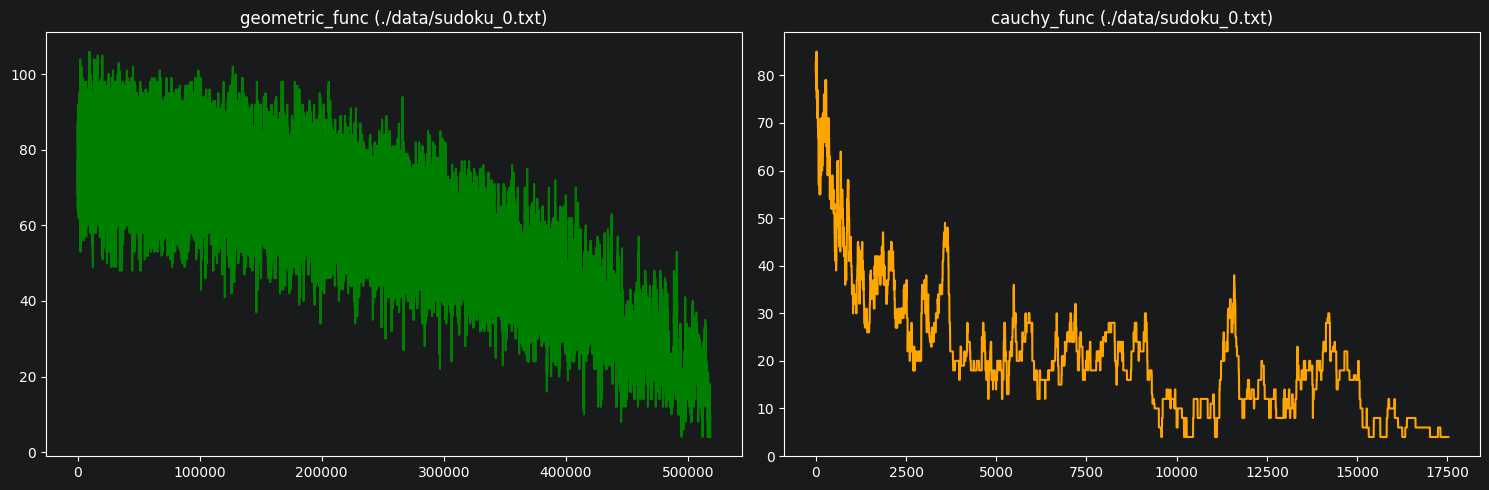

4
0


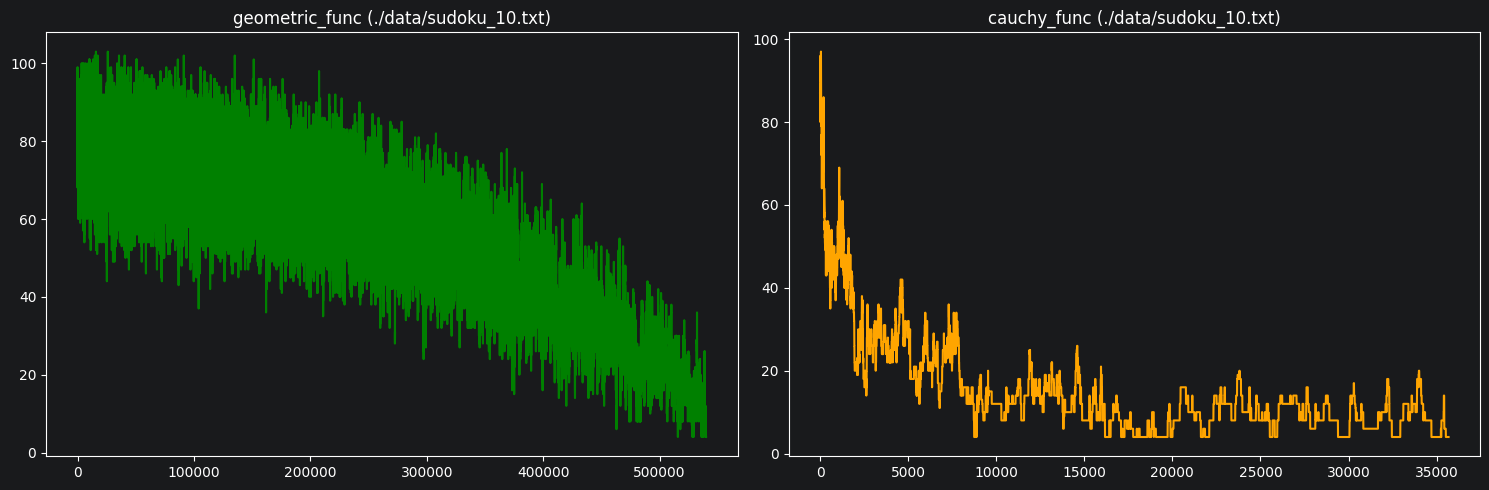

0
0


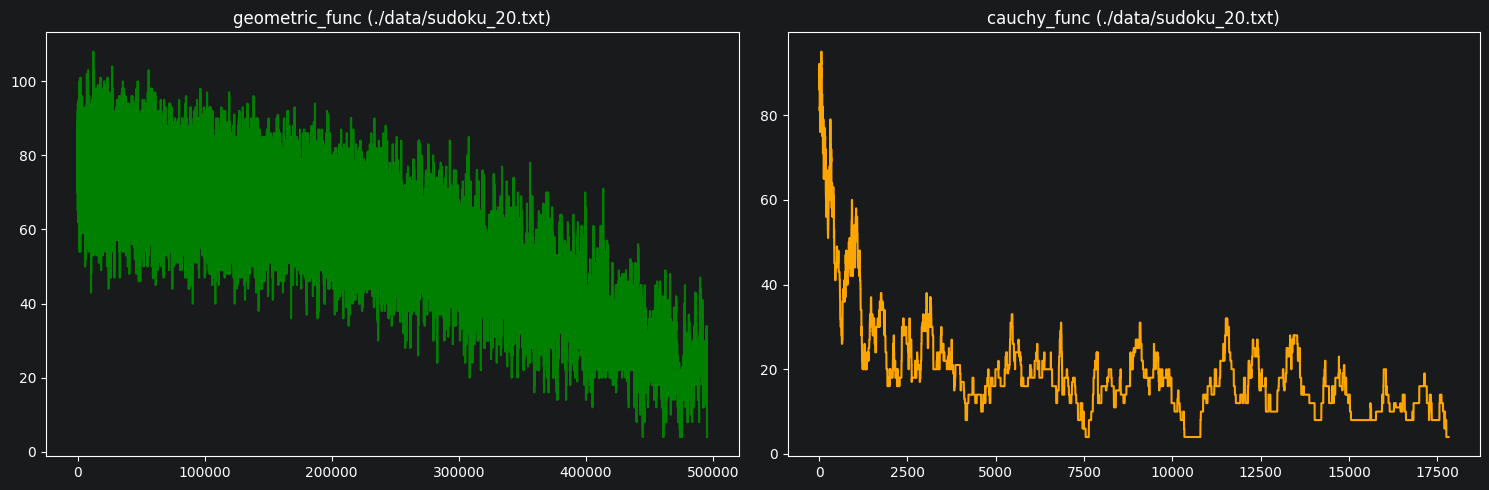

0
0


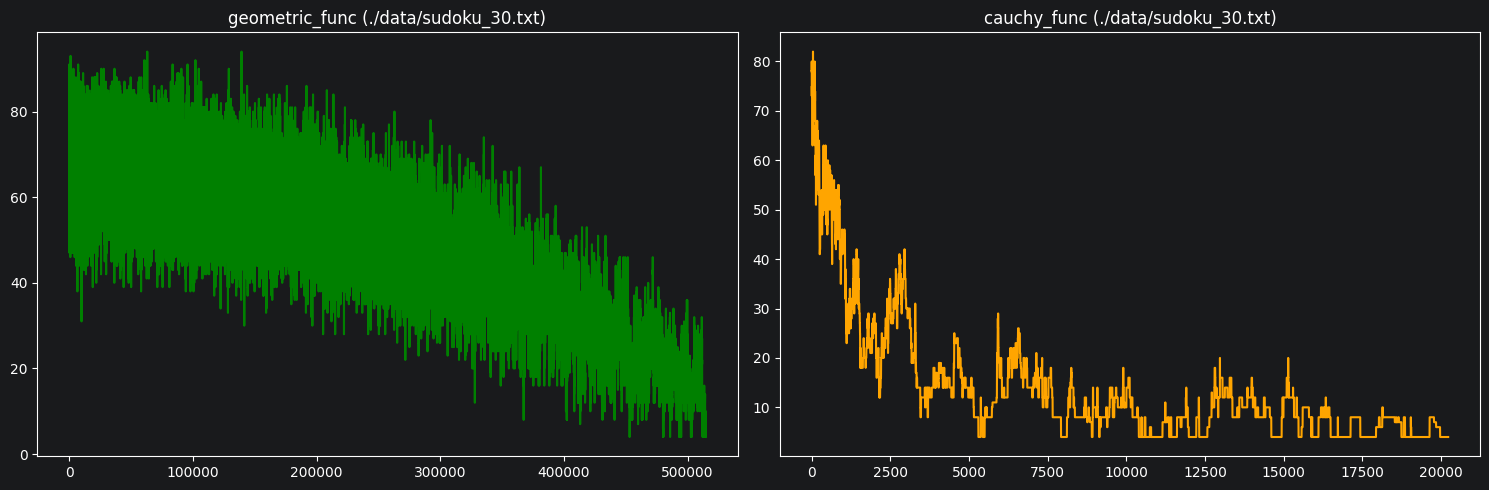

0
0


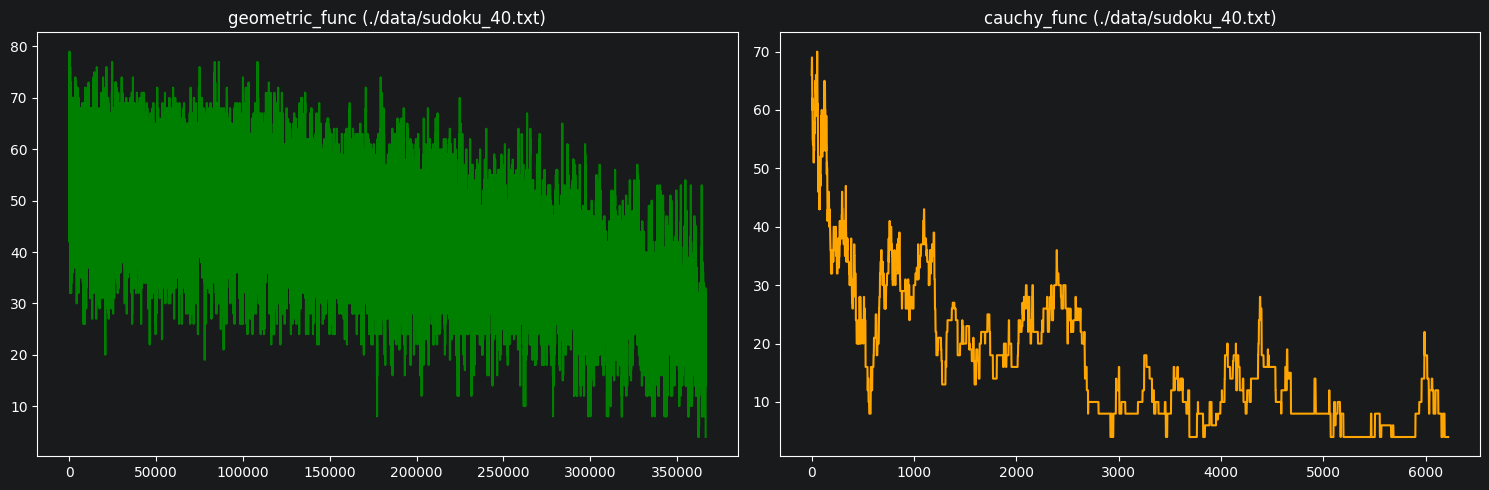

0
0


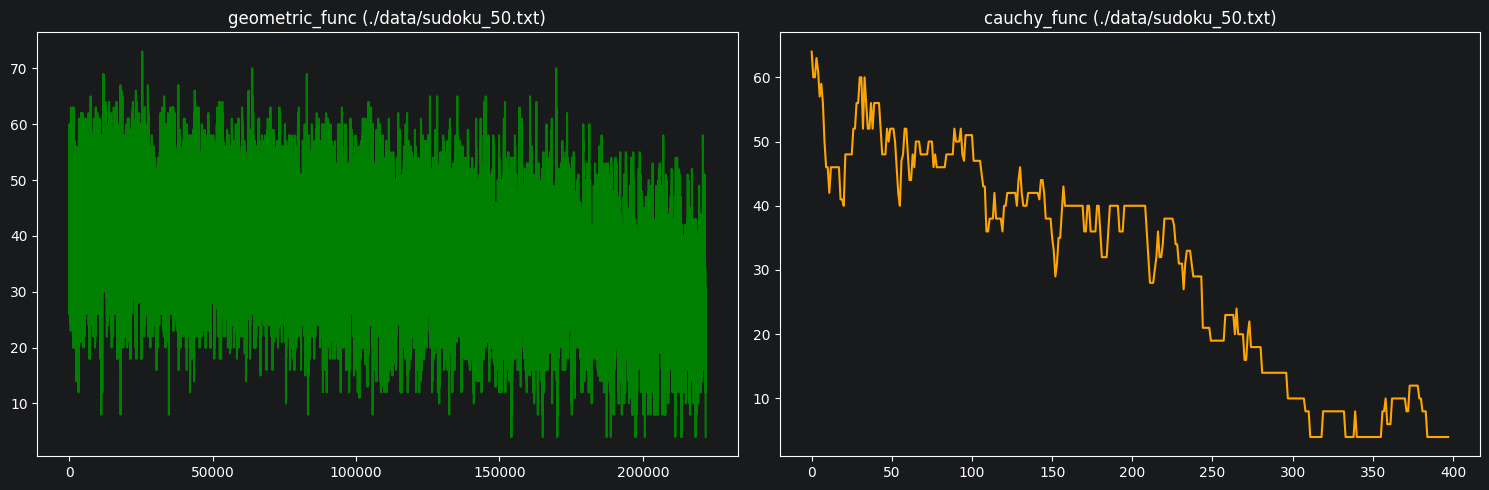

0
0


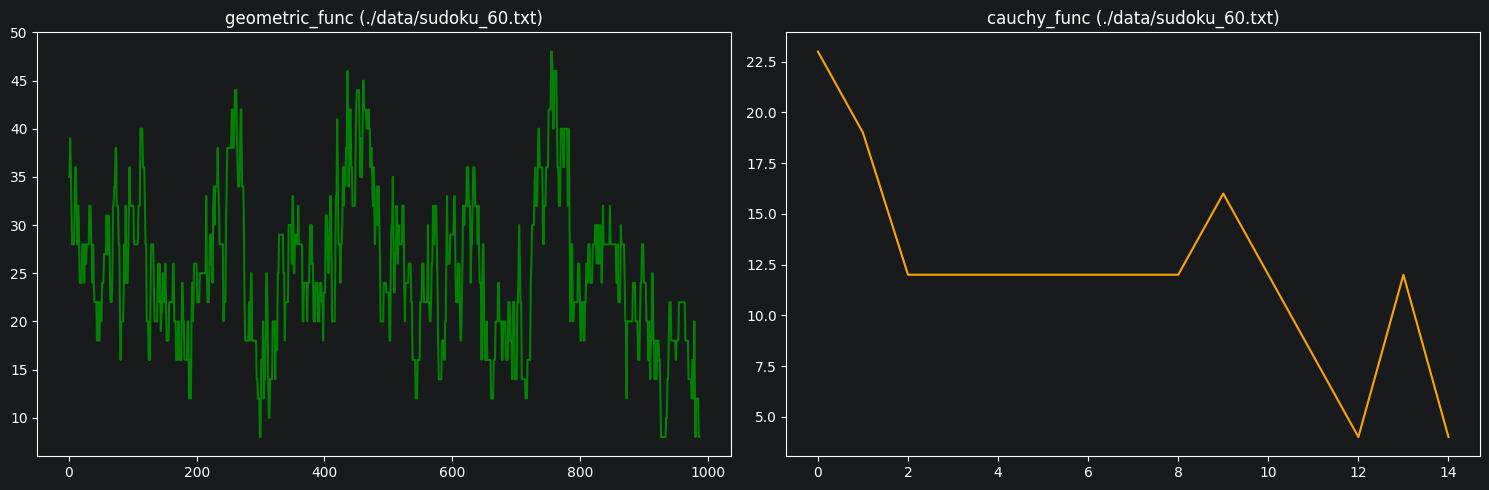

0
0


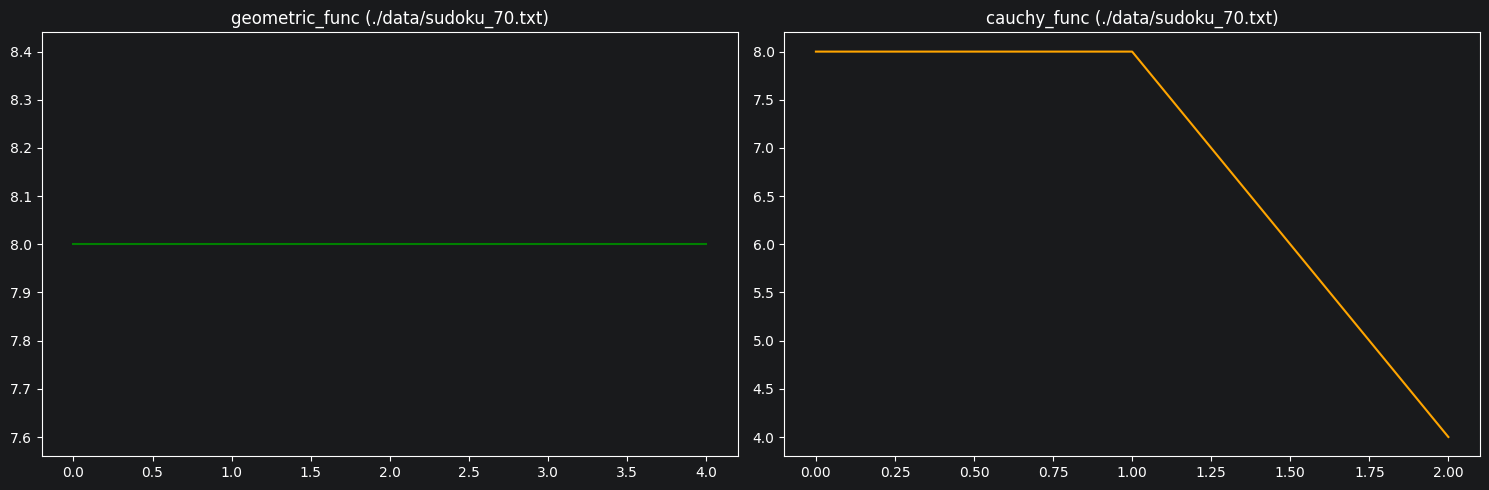

0
0


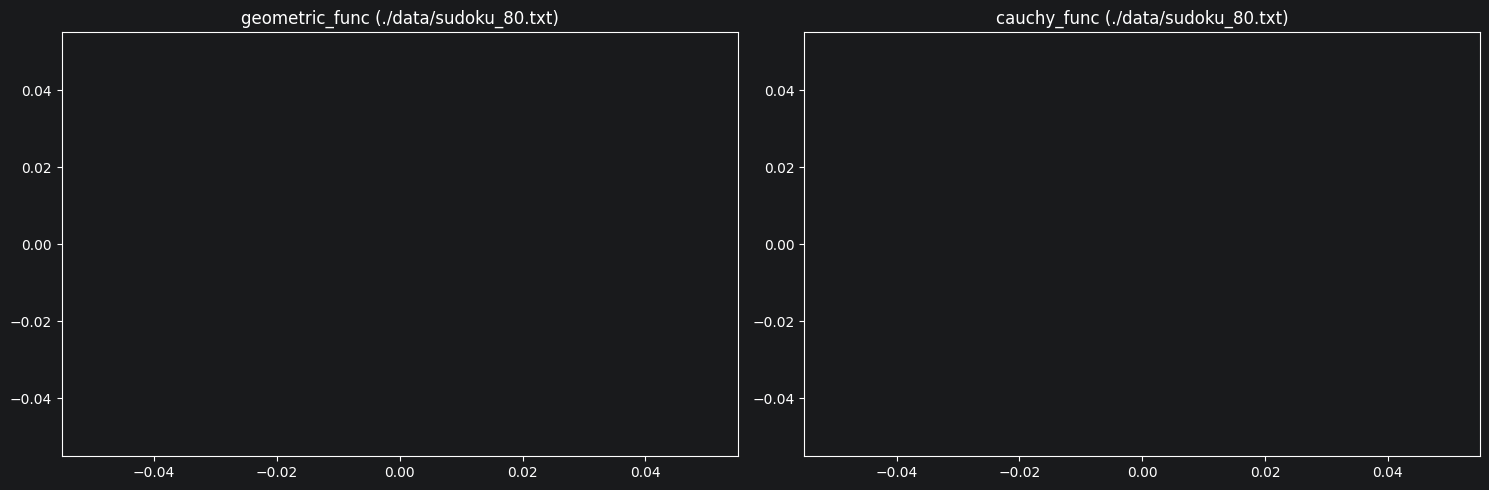

In [42]:
import re

#Ładowanie plansz z folderu
_, _, files = next(os.walk("./data/"))

files = sorted(files, key=lambda f: int(re.search(r'\d+', f).group()) if re.search(r'\d+', f) else 0)

iteration_list = []
end_values = []
cells = [10*c for c in range(9)]

temp_func = [geometric_func, cauchy_func]

for filename in files:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    filename = os.path.join("./data/", filename)

    for idx, temp_f in enumerate(temp_func): #Wybór funkcji temperatury
        m, p = load_from_file(filename)

        #Rozwiązywanie sudoku
        mem, output, temp, iterations = AS(m, params.T, params.err, params.alfa, params.beta, p, temp_f)

        iteration_list.append(iterations)

        end_values.append(get_value(mem))

        print(get_value(mem)) #Podgląd na wartość minimalną

        ax = axes[idx]
        ax.set_title(f"{temp_f.__name__} ({filename})")
        ax.plot(output, color='green' if idx == 0 else 'orange')

    plt.tight_layout()
    plt.show()

Na podstawie powyższych wykresów możemy wysnuć wniosek, iż funkcja temperatury w postaci Cauchego potrzebuje mniej iteracji by rozwiązać sudoku.

Poniżej znajduje się wykres liczby iteracji potrzebnych do rozwiązania sudoku. Jak możemy zauważyć wraz ze wzrostem liczby pustych komórek liczba iteracji wzrasta.

[17281, 18000, 16516, 17155, 12217, 7397, 33, 1, 1]


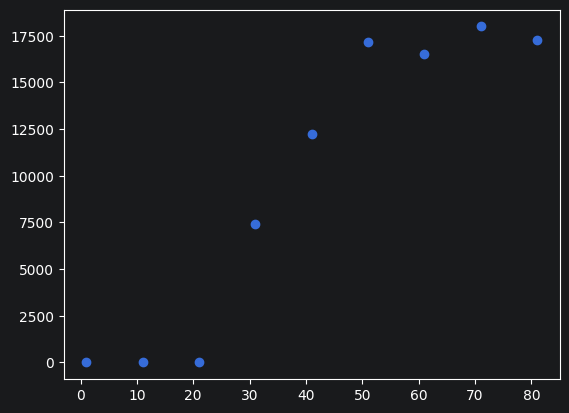

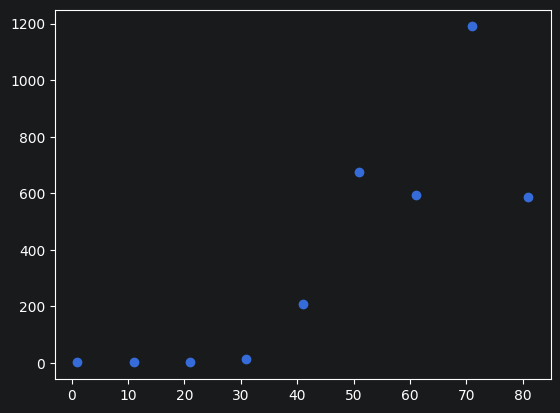

In [44]:
it_p = [n for i, n in enumerate(iteration_list) if i % 2 == 0]
it_np = [n for i, n in enumerate(iteration_list) if i % 2 != 0]

cells = [81-c for c in cells]

print(it_p)

plt.scatter(cells, it_p, label="end")
plt.show()

plt.scatter(cells, it_np, label="end")
plt.show()

Czy mój algorytm zawsze znajdzie rozwiązanie?

Nie zawsze, ponieważ może utknąć w minimum lokalnym z dwoma cyframi. Zdawałoby się, że wystarczy je zamienić. Ta zamiana wymusi inną zamianę i tak dalej. Takie minimum lokalne można by było spróbować opuścić ponownym rozgrzewaniem.

Istenieje prawdopodobieństwo rozwiązania każdej z plansz sudoku.